# Toulouse School on Machine Learning in Quantum Many-Body Physics

## Tutorial: Variational Monte Carlo with neural quantum states for the transverse-field Ising model

Filippo Vicentini, Damian Hofmann, Giuseppe Carleo


In this Tutorial we will introduce the open-source package [NetKet](https://www.netket.org/), and show some of its functionalities. We will guide you through a relatively simple quantum problem, that however will be a good guide also to address more complex situations. 

Specifically, we will study the transverse-field Ising model in one dimension: 

$$ 
\mathcal{H}=\Gamma\sum_{i}\sigma_{i}^{(x)}+V\sum_{i}\sigma_{i}^{(z)}\sigma_{i+1}^{(z)}. 
$$

In the following we assume periodic boundary conditions and we will count lattice sites starting from $ 0 $, such that $ i=0,1\dots L-1 $ and $i=L=0$. 

## 1. Defining the system and  Hamiltonian

The first step in our journey consists in defining the Hamiltonian we are interested in. 
For this purpose, we first need to define the kind of degrees of freedom we are dealing with (i.e. if we have spins, bosons, fermions etc). 
This is done specifying the Hilbert space of the problem. For example, let us concentrate on a problem with 20 spins-1/2.

When building hilbert spaces, in general, the first argument determines the size of the local basis and the latter defines how many modes you have.

In [1]:
import netket as nk

N = 20
hi = nk.hilbert.Spin(s=1 / 2, N=N)

NetKet's Hilbert spaces define the computational basis of the calculation, and are used to label and generate elements from it. 
The standard Spin-basis implicitly selects the `z` basis and elements of that basis will be elements $ v\in\{\pm 1\}^N $.

It is possible to generate random basis elements through the function `random_state(rng, shape, dtype)`, where the first argument must be a jax RNG state (usually built with `jax.random.PRNGKey(seed)`, second is an integer or a tuple giving the shape of the samples and the last is the dtype of the generated states.

In [2]:
import jax
import jax.numpy as jnp
hi.random_state(jax.random.PRNGKey(0), 3)

Array([[ 1., -1., -1.,  1., -1.,  1.,  1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1.,  1.,  1., -1., -1.],
       [ 1., -1.,  1.,  1., -1.,  1.,  1., -1.,  1., -1., -1., -1.,  1.,
         1.,  1.,  1., -1.,  1., -1.,  1.],
       [-1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1.,
         1.,  1.,  1., -1.,  1., -1.,  1.]], dtype=float32)

We now need to specify the Hamiltonian. For this purpose, we will use NetKet's ```LocalOperator``` (see details [here](https://www.netket.org/docs/_generated/operator/netket.operator.LocalOperator.html#netket.operator.LocalOperator)) which is the sum of arbitrary k-local operators. 

In this specifc case, we have a 1-local operator, $ \sigma^{(x)}_i $ and a 2-local operator, $ \sigma^{(z)}_i \sigma^{(z)}_j $. We then start importing the pauli operators. 



In [3]:
from netket.operator.spin import sigmax, sigmaz 

We now take $ \Gamma=-1 $ and start defining the 1-local parts of the Hamiltonian 

In [4]:
Gamma = -1
H = sum([Gamma*sigmax(hi,i) for i in range(N)])

Here we have used a list comprehension to (mildly) show off our ability to write one-liners, however you could have just added the terms one by one in an explicit loop instead (though you'd end up with a whopping 3 lines of code). 

We now also add the interaction terms, using the fact that NetKet automatically recognizes products of local operators as tensor products. 

In [5]:
V=-1
H += sum([V*sigmaz(hi,i)*sigmaz(hi,(i+1)%N) for i in range(N)])

In general, when manipulating NetKet objects, you should always assume that you can safely operate on them like 
you would in mathematical equations, therefore you can sum and multiply them with ease.

## 2. Exact Diagonalization

Now that we have defined the Hamiltonian, we can already start playing with it. For example, since the number of spins is large but still manageable for exact diagonalization, we can give it a try. 

In NetKet this is easily done converting our Hamiltonian operator into a sparse matrix of size $ 2^N \times 2^ N $. 

In [6]:
sp_h=H.to_sparse()
sp_h.shape

(1048576, 1048576)

Since this is just a regular scipy sparse matrix, we can just use any sparse diagonalization routine in there to find the eigenstates. For example, this will find the two lowest eigenstates  

In [7]:
from scipy.sparse.linalg import eigsh

eig_vals, eig_vecs = eigsh(sp_h, k=2, which="SA")

print("eigenvalues with scipy sparse:", eig_vals)

E_gs = eig_vals[0]

eigenvalues with scipy sparse: [-25.49098969 -25.41240947]


## 2. Jastrow Ansatz

We will now take a short-range Jastrow ansatz, entangling nearest and next-to nearest neighbors, of the form 

$$ \langle \sigma^{z}_1,\dots \sigma^{z}_N| \Psi_{\mathrm{jas}} \rangle = \exp \left( \sum_i J_1 \sigma^{z}_i\sigma^{z}_{i+1} + J_2 \sigma^{z}_i\sigma^{z}_{i+2} \right),$$

where the parameters $J_1$ and $J_2$ are to be learned. 

We can write the model using flax. 

In [8]:
from flax import linen as nn
class JasShort(nn.Module):
    
    @nn.compact
    def __call__(self, x):
        
        # Define the two variational parameters J1 and J2
        j1 = self.param(
            "j1", nn.initializers.normal(), (1,), float
        )
        j2 =self.param(
            "j2", nn.initializers.normal(), (1,), float
        )

        # compute the nearest-neighbor correlations
        corr1=x*jnp.roll(x,-1,axis=-1)
        corr2=x*jnp.roll(x,-2,axis=-1)

        # sum the output
        return jnp.sum(j1*corr1+j2*corr2,axis=-1)

The model itself is only a set of instructions on how to initialise the parameters and how to compute the result. 

To actually create a variational state with its parameters, the easiest way is to construct a Monte-Carlo-sampled Variational State. 
To do this, we first need to define a sampler.

In `netket.sampler` several samplers are defined, each with its own peculiarities. 
In the following example, we will be using a simple sampler that flips the spins in the configurations one by one.

You can read more about how the sampler works by checking the documentation with `?nk.sampler.MetropolisLocal`

You can play around with the variational state: for example, you can compute expectation values yourself or inspect it's parameters.
The parameters are stored as a set of nested dictionaries. In this case, the single parameter $\lambda$ is stored inside a (frozen) dictionary.
(The reason why the dictionary is frozen is a detail of Flax).

In [11]:
# Create an instance of the model. 
# Notice that this does not create the parameters, but only the specification of how the model is constructed and acts upon inputs/.
model = JasShort()

# Create the local sampler on the hilbert space
sampler = nk.sampler.MetropolisLocal(hi, n_chains=16, sweep_size=1)

# Construct the variational state using the model and the sampler above.
# n_samples specifies how many samples should be used to compute expectation
# values.
vstate = nk.vqs.MCState(sampler, model, n_samples=20*4000)

In [12]:
print(vstate)
print(vstate.parameters)

MCState(hilbert = Spin(s=1/2, N=20), sampler = MetropolisSampler(rule = LocalRule(), n_chains = 16, sweep_size = 1, reset_chains = False, machine_power = 2, dtype = <class 'float'>), n_samples = 80000)
{'j1': Array([0.01456597], dtype=float64), 'j2': Array([-0.00207526], dtype=float64)}


With a variational state, you can compute expectation values of operators using `vstate.expect`. For our `MCState`, this internally performs Monte Carlo sampling over `n_samples` spin configurations.

In [13]:
vstate.n_samples = 4000
E = vstate.expect(H)
print(type(E))
print(E)

<class 'netket.stats.mc_stats.Stats'>
-21.00 ± 0.15 [σ²=18.50, R̂=1.0257]


The return value of `.expect` is an object of type `Stats` which, beside the energy expectation value contains some statistics of the ensemble of local energies over which the energy is estimated.

The `Stats` object also has a dictionary representation:

In [14]:
print(E.to_dict())

{'Mean': -21.00176551218464, 'Variance': 18.504402787954184, 'Sigma': 0.1483570706791025, 'R_hat': 1.0256581593954486, 'TauCorr': 1.8788739007358792}


The `Stats` object contains the following diagnostics:

* The `Mean` over the local energy samples, which is an estimate of the quantum expectation value $\langle \hat H \rangle.$

* The `Variance` over the local energy samples, which is an estimate of the quantum variance $\langle(\delta\hat H)^2\rangle = \langle (\hat H - \langle \hat H \rangle)^2 \rangle.$

* The Monte Carlo standard error (MCSE) of the mean (as `Sigma`).

* An estimate `TauCorr` of the autocorrelation time over the Markov chains.

* `R_hat`, which is the so-called Gelman-Rubin split-R_hat diagnostic, which indicates whether the MCMC chain is converged (see below).

If you are close to an eigenstate of the operators, the variance should be close to 0. (In an exact eigenstate, the local energy is constant and therefore the variance is exactly zero.)

The Gelman-Rubin diagnostic will be $\hat{R}\approx 1$ if the Markov chains are converged, while it will be larger than $1$ if your sampling has not converged.
As a rule of thumb, look out for $|\hat{R}| > 1.1$, and if that occurs consistently, check if you need more samples or if you MCMC scheme is even consistent with your system. (This is a somewhat weak criterion. Modern MCMC literature tends to recommend $|\hat{R}| > 1.01$ to discard a sample. NQS optimization can still work with the less stringent criterion, but if you see stability problems, keep this in mind.)

You can also investigate the correlation time of your estimator, $\tau$. If $\tau\gg1$ then your samples are very correlated and you most likely have some issues with your sampling scheme.

You can also access the fields individually:
Note that if you run your calculation using MPI on different processes/machines, those estimators will return the mean, error and estimators of all the samples across all the processes.

In [15]:
optimizer = nk.optimizer.Sgd(learning_rate=0.01)

gs = nk.driver.VMC(H, optimizer, variational_state=vstate)
# construct the logger
log=nk.logging.RuntimeLog()
print(vstate.n_samples)
# One or more logger objects must be passed to the keyword argument `out`.
gs.run(n_iter=50, out=log)

print(f"Final optimized parameters: j1={vstate.parameters['j1']}, j2={vstate.parameters['j2']}")

jas_energy=vstate.expect(H)
error=abs((jas_energy.mean-eig_vals[0])/eig_vals[0])
print(f"Optimized energy : {jas_energy}")
print(f"relative error   : {error}")

4000


  0%|                                                    | 0/50 [00:00<?, ?it/s]

Final optimized parameters: j1=[0.24564315], j2=[0.09235837]
Optimized energy : -25.321 ± 0.028 [σ²=0.566, R̂=1.0679]
relative error   : 0.00665262527470344


Loggers that work together with optimisation drivers are defined in `nk.logging`. In this example we use `RuntimeLog`, which keeps the metrics in memory. You could also use `JsonLog`, which stores data to a json file which can be later read as a dict or `TensorBoardLog` which connects to [TensorBoard](https://www.tensorflow.org/tensorboard).

In [16]:
data_jastrow = log.data
print(data_jastrow)

{'Energy': History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 48, 49] (50 steps),
)}


These report several intermediate quantities, that can be easily plotted. For example we can plot the value of the energy (with its error bar) at each optimization step.  

Text(0, 0.5, 'Energy')

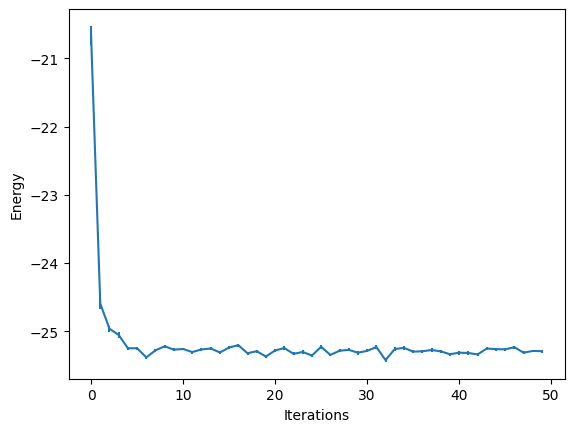

In [17]:
from matplotlib import pyplot as plt

plt.errorbar(data_jastrow["Energy"].iters, data_jastrow["Energy"].Mean, yerr=data_jastrow["Energy"].Sigma)
plt.xlabel('Iterations')
plt.ylabel('Energy')